# Transfer Learning 기반의 CNN 모델 학습 - 실습

---

## 학습 개요

1. **학습 주제**
  - **전이 학습(Transfer Learning)**: 사전 학습된 모델의 가중치를 새로운 문제에 활용하는 방법론
  - **Linear Probing vs Fine-tuning**: 사전 학습 모델을 활용하는 두 가지 핵심 전략
  - **Vision Transformer(ViT)**: Transformer 아키텍처를 이미지 분류에 적용한 최신 모델

2. **학습 목표**
  - 전이 학습의 개념과 효과를 이해하고, **Linear Probing과 Fine-tuning의 차이**를 설명할 수 있다.
  - 사전 학습된 **ResNet-18 모델**을 불러와 CIFAR-10 데이터셋에 맞게 수정하고 학습시킬 수 있다.
  - **데이터 증강(Augmentation)**과 **학습률 스케줄러(Scheduler)**를 활용하여 모델 성능을 개선할 수 있다.
  - HuggingFace Transformers 라이브러리를 활용하여 **Vision Transformer(ViT) 모델**로 이미지 분류를 수행할 수 있다.
  - 각 학습 단계에서 **전이학습의 효과를 정량적으로 분석**하고 해석할 수 있다.

3. **핵심 개념**
  - **전이 학습(Transfer Learning)**: 대규모 데이터셋(ImageNet)으로 사전 학습된 모델의 특징 추출 능력을 활용하여 새로운 태스크에 빠르게 적응시키는 기법
  - **Linear Probing**: 사전 학습 모델의 특징 추출 부분(backbone)을 동결하고 분류층만 학습시키는 방법
  - **Fine-tuning**: 사전 학습 모델의 전체 또는 일부를 새로운 데이터로 추가 학습시켜 성능을 극대화하는 방법
  - **데이터 증강(Augmentation)**: 학습 데이터에 무작위 변환을 적용하여 모델의 일반화 성능을 향상시키는 기법
  - **학습률 스케줄러(Learning Rate Scheduler)**: 학습 진행에 따라 학습률을 동적으로 조정하여 최적화 성능을 개선하는 기법
  - **Vision Transformer(ViT)**: 이미지를 패치로 분할하여 Transformer 인코더로 처리하는 모델 구조

4. **선행 지식**
  - Python 기본 문법 및 PyTorch 기초 (텐서 연산, 모델 정의, 학습 루프)
  - CNN 기본 개념 (Convolution, Pooling, Fully Connected Layer)
  - 이미지 분류 문제의 이해
  - (선택) ResNet 아키텍처의 기본 구조


## 실습 구성

1. **학습 방향**

- **실습 구성 방식**
  - 각 단계별로 TODO 영역을 채우며 학습자가 직접 구현

- **Required Package**
  ```
  python==3.11
  numpy>=2.0.0
  matplotlib>=3.8.0
  tqdm>=4.66.0
  torch>=2.1.0
  torchvision>=0.16.0
  datasets>=3.0.0
  transformers==4.57.1
  hf_transfer>=0.1.9
  ```
  - `ViTImageProcessor` 사용을 위해 `transformers` 버전은 `4.57.1`으로 고정합니다.

- **Step 요약**
  - **Step 1 (25분)**: Linear Probing - ResNet-18의 특징 추출 부분을 동결하고 분류층만 학습하여 전이 학습의 기본 효과 체험
  - **Step 2 (20분)**: Fine-tuning & Augmentation - 데이터 증강과 전체 모델 학습, 학습률 스케줄러를 적용하여 성능 극대화
  - **Step 3 (15분)**: Vision Transformer Inference - HuggingFace의 ViT 모델로 이미지 분류를 수행하고 결과 시각화
  - **총 소요시간(권장)**: 60분

2. **데이터셋 개요 및 저작권 정보**
  - **데이터셋 명**: CIFAR-10
  - **데이터셋 개요**: 10개 클래스(airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)로 구성된 32×32 컬러 이미지 데이터셋입니다. 훈련 데이터 50,000장, 테스트 데이터 10,000장으로 구성됩니다.
  - **사용 목적**: 이미지 분류 모델 학습 및 전이 학습 효과 검증
  - **저작권/출처**: Alex Krizhevsky, Vinod Nair, Geoffrey Hinton이 공개한 데이터셋으로, 연구 및 교육 목적으로 자유롭게 사용 가능합니다.
  - **주의사항**: 본 데이터셋은 저해상도(32×32)이므로, 실무 적용 시에는 더 고해상도 데이터를 사용해야 합니다.

3. **문제 설명**
  - **문제 개요**: 이 실습은 **전이 학습(Transfer Learning)의 전체 파이프라인**을 익히기 위해 설계되었습니다. 학습자는 사전 학습된 ResNet-18 모델을 활용하여 **Linear Probing과 Fine-tuning의 차이**를 직접 체험하고, 각 단계에서 **전이학습의 효과를 정량적으로 분석**할 수 있어야 합니다.

  - **요구사항 요약**
    - **Step 1**: 사전 학습된 ResNet-18의 마지막 층만 학습(Linear Probing)하여 기본 성능 확보
    - **Step 2**: 데이터 증강과 전체 모델 Fine-tuning으로 성능 극대화
    - **Step 3**: HuggingFace ViT 모델로 추론 수행 및 결과 시각화

4. **학습 문제: Step–TODO 구체 설명**
  - **Step 1 — Linear Probing**
    - **TODO 1**: 데이터셋 준비 *(연결 학습개념: 이미지 전처리 / 정규화)* - `train_transform`과 `test_transform`을 구성하여 이미지를 (224, 224)로 리사이즈하고, 텐서로 변환하며, 전체 학습데이터의 평균/표준편차로 정규화를 진행합니다.
    - **TODO 2**: Linear Probing 설정 *(연결 학습개념: 모델 구조 이해 / 파라미터 동결)* - ResNet-18의 마지막 분류층(fc)을 CIFAR-10의 10개 클래스에 맞게 교체하고, fc층을 제외한 나머지 레이어의 가중치를 동결합니다.
    - **TODO 3**: 모델 학습 설정 *(연결 학습개념: PyTorch 학습 루프 / 최적화)* - 손실 함수(CrossEntropyLoss)와 옵티마이저(SGD, lr=0.001)를 정의하고, 학습 루프를 구현합니다(gradient 초기화 → forward pass → loss 계산 → backward pass → 파라미터 업데이트).
    - **1줄 요약**: 사전 학습 모델의 특징 추출 능력을 활용하여 최소한의 학습으로 빠르게 적응시킵니다.

  - **Step 2 — Fine-tuning & Augmentation**
    - **TODO 4**: 데이터 증강 적용 *(연결 학습개념: 데이터 증강 / 일반화 성능 향상)* - `train_transform_aug`에 RandomCrop과 RandomHorizontalFlip을 추가하여 데이터 다양성을 높입니다.
    - **TODO 5**: Fine-tuning 설정 *(연결 학습개념: Fine-tuning / 전체 모델 학습)* - 전체 레이어의 동결을 해제(`requires_grad=True`)하고, 낮은 학습률(0.0005)로 새로운 옵티마이저를 선언합니다.
    - **1줄 요약**: 데이터 증강과 전체 모델 학습으로 성능을 극대화하고 일반화 능력을 향상시킵니다.

  - **Step 3 — Vision Transformer Inference**
    - **TODO 6**: ViT 모델 로드 *(연결 학습개념: HuggingFace Transformers / 사전 학습 모델 활용)* - `ViTImageProcessor`를 사용하여 이미지 전처리기를 불러오고, `ViTForImageClassification`으로 사전 학습된 ViT 모델을 불러옵니다.
    - **1줄 요약**: Transformer 기반 최신 비전 모델을 활용하여 간편하게 이미지 분류를 수행합니다.


## Import & Install

먼저 실습에 필요한 라이브러리를 불러오고, 재현성을 위해 시드를 설정합니다.

In [1]:
# 공통 실습 환경 설치 (최초 1회 실행)
# %pip install -q \
#     "numpy>=2.0.0" \
#     "matplotlib>=3.8.0" \
#     "tqdm>=4.66.0" \
#     "torch>=2.1.0" \
#     "torchvision>=0.16.0" \
#     "datasets>=3.0.0" \
#     "transformers==4.57.1" \
#     "hf_transfer>=0.1.9"


In [2]:
import random

import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm

# @@ --- cuda cache 비우기 ---
torch.cuda.empty_cache()

# 재현성을 위한 시드 고정
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device 설정 (GPU 사용 가능하면 GPU, 아니면 CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Step 1: Linear Probing

### Concept Check: 전이학습(Transfer Learning)이란?

전이학습(Transfer Learning)은 **이미 학습된 모델의 가중치를 새로운 문제에 활용하는 방법**입니다.

#### CNN의 특징 추출 구조

이미지를 분류하는 CNN은 일반적으로 다음과 같은 구조를 가집니다:

```
[입력 이미지] → [특징 추출 (Convolution + Pooling)] → [분류 (Fully Connected Layers)] → [출력]
```

- **특징 추출 부분**: 합성곱(Convolution)과 풀링(Pooling)을 통해 이미지의 저수준 특징(엣지, 색상)부터 고수준 특징(물체의 형태, 질감)까지 점진적으로 추출합니다.
- **분류 부분**: Fully Connected Layer가 추출된 특징을 기반으로 최종 분류 결정을 내립니다.

#### 왜 전이학습이 효과적인가?

CNN이 학습하는 **저수준 특징들(엣지, 색상, 선, 질감)은 매우 범용적**이어서 다양한 이미지 데이터셋에서 공통으로 유용합니다. 예를 들어:
- ImageNet(1000개 클래스, 100만+ 이미지)으로 학습된 모델은 **일반적인 시각 패턴**을 이미 학습했습니다.
- 이 지식을 CIFAR-10(10개 클래스, 6만 이미지)에 적용하면 **처음부터 학습하는 것보다 훨씬 빠르고 효과적**입니다.

반면, **마지막 분류층은 태스크에 특화된 정보**(예: ImageNet의 1000개 클래스)를 담고 있어 새로운 태스크에 맞게 재학습이 필요합니다.

#### Linear Probing vs Fine-tuning 비교

전이학습을 적용하는 두 가지 주요 전략이 있습니다:

| 구분 | Linear Probing | Fine-tuning |
|------|----------------|-------------|
| **정의** | 특징 추출 부분을 동결하고 분류층만 학습 | 전체 또는 일부 모델을 추가 학습 |
| **학습 파라미터** | 분류층만 (전체의 ~1%) | 전체 모델 (100%) |
| **학습 속도** | 매우 빠름 (분 단위) | 상대적으로 느림 (시간 단위) |
| **성능** | 기본 성능 확보 | 최고 성능 달성 |
| **과적합 위험** | 낮음 | 높음 (데이터가 적을 때) |
| **적용 시나리오** | 데이터가 적거나 빠른 프로토타이핑이 필요할 때 | 충분한 데이터와 컴퓨팅 자원이 있을 때 |
| **학습률** | 상대적으로 큼 (0.001~0.01) | 상대적으로 작음 (0.0001~0.001) |

#### 전이학습 효과 관찰 포인트

이번 실습에서는 다음 지표들을 통해 전이학습의 효과를 확인할 수 있습니다:

1. **학습 속도**: 사전 학습 모델은 처음부터 학습하는 것보다 훨씬 빠르게 수렴합니다.
2. **초기 성능**: 첫 에포크부터 이미 높은 정확도를 보입니다(Random 초기화는 ~10%, 전이학습은 ~60%+).
3. **최종 성능**: Linear Probing만으로도 70%+ 정확도를 달성할 수 있습니다.
4. **Fine-tuning 효과**: 전체 모델을 학습시키면 90%+ 정확도까지 향상됩니다.

이제 Linear Probing부터 시작해봅시다!

### 데이터 준비 및 전처리
다음으로 학습을 위한 데이터를 준비합니다.

TorchVision을 이용해 CIFAR-10 데이터셋을 불러오고, 필요한 전처리를 적용합니다.
1. CIFAR-10 데이터를 ResNet-18의 입력에 맞게 224x224로 변환해주어야 합니다.
2. 데이터에는 정규화를 적용합니다.

정규화에는 CIFAR-10 데이터셋의 픽셀 평균과 표준편차 값을 사용하며, 이는 모델이 입력을 보다 안정적으로 받아들이게 도와줍니다.

In [3]:
# CIFAR-10 데이터셋 로드 (train 50,000장, test 10,000장)
# --- CIFAR-10 데이터셋 로드 ---
# root: 데이터가 저장될 경로
# train=True: 훈련용 데이터셋을 불러옴
# download=True: 해당 경로에 데이터가 없으면 다운로드
# transform: 데이터 변환기 적용 -> 데이터를 먼저 확인하기 위해 False로 설정
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=False)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=False)

print(trainset.data.shape, testset.data.shape)

(50000, 32, 32, 3) (10000, 32, 32, 3)


### TODO 1: 데이터셋 준비

**요구사항**: 학습데이터와 테스트데이터 이미지를 전처리하기 위한 `train_transform`과 `test_transform`을 `torchvision.transform.Compose`를 통해 구성해주세요.
1. (224, 224) 사이즈로 리사이즈 해주세요.
2. 이미지를 텐서로 변환해주세요.
3. 전체 학습데이터의 평균/표준편차를 계산해 이에 대해 정규화를 진행해주세요.

In [4]:
# CIFAR_10 데이터셋의 평균과 표준편차 계산
data_tensor = torch.from_numpy(trainset.data)

# 변환을 위한 평균/표준편차 계산 (배치, 높이, 너비 차원에 대해)
mean = torch.mean(data_tensor.float() / 255.0, dim=(0, 1, 2))
std = torch.std(data_tensor.float() / 255.0, dim=(0, 1, 2))

# 변환(transform)선언
# 1. (224, 224) 사이즈로 리사이즈 해주세요.
# 2. 이미지를 텐서로 변환해주세요.
# 3. 전체 학습데이터의 평균/표준편차를 계산해 이에 대해 정규화를 진행해주세요.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

여러분들이 제작한 `transform`을 기반으로 학습데이터와 검증데이터를 다시 선언해봅시다. 그리고 DataLoader로 변환해봅시다.

In [5]:
# root: 데이터가 저장될 경로
# train=True: 훈련용 데이터셋을 불러옴
# download=True: 해당 경로에 데이터가 없으면 다운로드
# transform: 위에서 정의한 데이터 변환기 적용
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# DataLoader는 데이터를 미니배치(mini-batch) 단위로 묶어주는 역할을 함
# batch_size: 한 번에 모델에 입력할 데이터(이미지)의 개수
# shuffle=True: 훈련 시 데이터를 무작위로 섞어 모델이 데이터 순서에 과적합되는 것을 방지
# shuffle=False: 평가 시 데이터 순서를 고정해 재현 가능한 검증을 수행
# pin_memory=True: CPU 메모리를 고정해 GPU로 텐서를 더 빠르게 전송
# num_workers=8: 데이터 로딩에 사용할 병렬 프로세스(worker) 수
trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True, pin_memory=True, num_workers=8)
testloader  = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, pin_memory=True, num_workers=8)
print("훈련 배치 개수:", len(trainloader), "테스트 배치 개수:", len(testloader))


훈련 배치 개수: 196 테스트 배치 개수: 40


### 모델 준비 및 Linear Probing 설정

다음으로 TorchVision으로 사전학습된 ResNet-18 모델을 불러오고, CIFAR-10에 맞도록 수정하겠습니다. 기본 ResNet-18 모델은 ImageNet의 1000개 클래스로 훈련되었으므로 마지막 출력 뉴런 수가 1000입니다. 이를 CIFAR-10의 10개 클래스로 바꾸기 위해 최종 Fully Connected Layer를 새로운 레이어로 교체합니다.

새로 추가된 Fully Connected Layer를 제외한 나머지 모델의 가중치는 동결시켜, 업데이트가 되지 않도록 합니다.

In [6]:
# ImageNet 데이터로 사전 학습된 ResNet-18 모델을 불러옴
# pretrained=True 옵션은 학습된 가중치(weights)를 함께 가져오라는 의미
model = torchvision.models.resnet18(pretrained=True)

/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
# 모델 구조 출력. 마지막 레이어 (Fully Connected Layer)의 이름이 fc인 것을 확인
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### TODO 2: Linear Probing 설정
**요구사항**: 선형 프로빙을 위해 두 가지를 수행해주세요.
1. **마지막 분류층(Fully Connected Layer) 교체**: ResNet-18의 마지막 층을 수행해주세요. 기존 ResNet-18의 마지막 층(model.fc)은 ImageNet의 1000개 클래스를 분류합니다. 우리는 CIFAR-10의 10개 클래스를 분류하도록 새로운 `nn.Linear` 레이어로 교체해야 합니다.
2. 선형 프로빙을 위해 ResNet-18을 1에서 선언한 마지막 층을 제외하고 업데이트가 되지 않도록 가중치를 동결하세요.

In [8]:
# 1. 마지막 분류층(Fully Connected Layer) 교체
# ResNet-18의 마지막 층을 수행해주세요.
# 기존 ResNet-18의 마지막 층(model.fc)은 ImageNet의 1000개 클래스를 분류합니다.
# 우리는 CIFAR-10의 10개 클래스를 분류하도록 새로운 `nn.Linear` 레이어로 교체해야 합니다.
model.fc = nn.Linear(model.fc.in_features, 10)


# 2. 선형 프로빙을 위해 ResNet-18을 1에서 선언한 마지막 층을 제외하고 업데이트가 되지 않도록 가중치를 동결하세요.
# `param.requires_grad = False`로 설정하면 해당 파라미터는 학습 중에 업데이트되지 않습니다.
for name, param in model.named_parameters():
    if "fc" not in name:  # fc 층이 아닌 경우
        param.requires_grad = False

# 장치를 GPU로 이동
model = model.to(device)

### TODO 3: 모델 학습 설정

**요구사항**: 모델이 준비되었으면 모델의 마지막 레이어 (분류층)만 학습시킵니다. 다음 요구사항에 맞춰 모델 학습을 위한 코드를 마무리해주세요.
1. 손실 함수 (`criterion`)로는 다중 클래스 분류를 위한 크로스 엔트로피 오차(`nn.CrossEntropyLoss`)를 사용합니다.
2. 옵티마이저 (`optimizer`)로는 마지막 레이어 (분류층) 파라미터만 업데이트하도록 SGD(Stochastic Gradient Descent)를 사용합니다. 학습률은 0.001로 설정해주세요.
3. 학습을 위한 for 루프도 마무리해주세요. 이전에 진행한 챕터 1-2의 실습과 과제를 떠올려주세요.
    1. 옵티마이저의 그래디언트(gradient)를 0으로 초기화
    2. 모델에 입력을 넣어 순전파(forward pass) 진행 및 출력(outputs) 계산
    3. 모델의 출력과 실제 정답을 비교하여 손실(loss) 계산
    4. 역전파(backward pass)를 통해 각 파라미터에 대한 그래디언트 계산
    5. 옵티마이저를 사용해 모델의 파라미터(가중치)를 업데이트

In [9]:
# 1. 손실 함수 (`criterion`)로는 다중 클래스 분류를 위한 크로스 엔트로피 오차(`nn.CrossEntropyLoss`)를 사용합니다.
criterion = nn.CrossEntropyLoss()

# 2. 옵티마이저 (`optimizer`)로는 마지막 레이어 (분류층) 파라미터만 업데이트하도록 SGD(Stochastic Gradient Descent)를 사용합니다.
# 학습률은 0.001로 설정해주세요.
optimizer = optim.SGD(model.fc.parameters(), lr=0.001)

# 3. 학습을 위한 for 루프도 마무리해주세요. 이전에 진행한 챕터 1-2의 실습과 과제를 떠올려주세요.
num_epochs = 5
for epoch in tqdm(range(num_epochs)):
    model.train()       # 모델을 학습 모드로 설정
    running_loss = 0.0  # 에포크 동안의 총 손실을 기록할 변수

    # trainloader에서 미니배치 단위로 데이터를 가져와 반복
    for xb, yb in trainloader:
        # 입력 데이터와 정답 레이블을 지정된 장치(GPU)로 이동
        xb, yb = xb.to(device), yb.to(device)

        # 3.1 옵티마이저의 그래디언트(gradient)를 0으로 초기화
        optimizer.zero_grad()

        # 3.2 모델에 입력을 넣어 순전파(forward pass) 진행 및 출력(outputs) 계산
        outputs = model(xb)

        # 3.3 모델의 출력과 실제 정답을 비교하여 손실(loss) 계산
        loss = criterion(outputs, yb)

        # 3.4 역전파(backward pass)를 통해 각 파라미터에 대한 그래디언트 계산
        loss.backward()

        # 3.5 옵티마이저를 사용해 모델의 파라미터(가중치)를 업데이트
        # requires_grad=True로 설정된 파라미터만 업데이트됨 (여기서는 fc 층만)
        optimizer.step()

        # 현재 배치의 손실을 running_loss에 더함
        running_loss += loss.item()

    # 전체 에포크가 끝난 후 평균 훈련 손실을 계산하고 출력
    avg_loss = running_loss / len(trainloader)
    print(f"[Epoch {epoch+1}/{num_epochs}] 평균 훈련 손실: {avg_loss:.4f}")

 20% 1/5 [00:25<01:41, 25.41s/it]

[Epoch 1/5] 평균 훈련 손실: 2.2002


 40% 2/5 [00:48<01:11, 23.92s/it]

[Epoch 2/5] 평균 훈련 손실: 1.8465


 60% 3/5 [01:11<00:47, 23.51s/it]

[Epoch 3/5] 평균 훈련 손실: 1.6053


 80% 4/5 [01:34<00:23, 23.39s/it]

[Epoch 4/5] 평균 훈련 손실: 1.4324


100% 5/5 [01:57<00:00, 23.50s/it]

[Epoch 5/5] 평균 훈련 손실: 1.3078


### 모델 평가

훈련이 완료된 모델을 평가 모드(eval)로 전환한 뒤, CIFAR-10 테스트 데이터 10,000장에 대한 정확도를 측정해보겠습니다. 학습 시와 마찬가지로 입력을 device(GPU)에 올리고, torch.no_grad() 컨텍스트 내에서 출력을 예측하여 성능을 산출합니다. ImageNet에 사전학습된 ResNet-18을 사용했기 때문에, 마지막 레이어만 학습하더라도 CIFAR-10 데이터에 빠르게 적응한 것을 확인할 수 있습니다.

**관찰 포인트**
- Linear Probing만으로도 70%+ 정확도를 달성했나요?
- 학습 손실이 빠르게 감소했나요?
- Random 초기화 대비 얼마나 빠르게 수렴했나요?

In [10]:
# 모델을 평가 모드로 설정
# 이 모드에서는 드롭아웃(Dropout)이나 배치 정규화(Batch Normalization) 등이 비활성화되어 일관된 예측 결과를 얻을 수 있음
model.eval()

correct = 0   # 맞춘 예측 개수
total = 0     # 전체 데이터 개수

# 그래디언트 계산을 비활성화하는 컨텍스트
with torch.no_grad():
    # testloader에서 미니배치 단위로 데이터를 가져와 반복
    for xb, yb in tqdm(testloader):

        # 입력 데이터와 정답 레이블을 장치(GPU)로 이동
        xb, yb = xb.to(device), yb.to(device)

        # 모델에 입력을 넣어 출력 계산
        outputs = model(xb)
        _, predicted = torch.max(outputs.data, 1)
        total += yb.size(0) # 현재 배치의 데이터 개수를 total에 더함

        # 예측이 정답과 일치하는 개수를 세어 correct에 더함
        correct += (predicted == yb).sum().item()

# 전체 정확도 계산 및 출력
accuracy = 100 * correct / total
print(f"테스트 데이터 정확도 (Linear Probing): {accuracy:.2f}%")

100% 40/40 [00:04<00:00,  8.10it/s]

테스트 데이터 정확도 (Linear Probing): 67.67%


## Step 2: Fine-tuning & Data Augmentation

### Concept Check: Fine-tuning과 성능 향상 기법

두 번째 섹션에서는 첫 번째 단계의 결과를 바탕으로 성능을 향상시키기 위한 기법들을 적용합니다. 주요 전략은 다음과 같습니다:

#### 1. 데이터 증강(Data Augmentation)

학습 데이터에 무작위 변환을 적용하여 데이터 다양성을 높이고 과적합을 방지합니다.

**주요 증강 기법:**
- `RandomCrop`: 이미지를 무작위로 잘라내어 위치 변화에 강인하게 만듦
- `RandomHorizontalFlip`: 좌우 반전으로 좌우 대칭성 학습
- `ColorJitter`: 밝기, 대비, 채도를 무작위로 변경
- `RandomRotation`: 회전 변환으로 각도 변화에 대응

**효과:**
- 제한된 데이터로도 다양한 상황을 학습 가능
- 과적합 방지 및 일반화 성능 향상
- 테스트 시에는 증강을 적용하지 않음 (일관된 평가를 위해)

#### 2. Fine-tuning

동결했던 특징 추출 부분(backbone)을 풀고 전체 모델을 학습시킵니다.

**Fine-tuning 전략:**
- **전체 Fine-tuning**: 모든 층을 학습 (가장 높은 성능)
- **부분 Fine-tuning**: 상위 몇 개 층만 학습 (계산 효율적)
- **Layer-wise Learning Rate**: 하위 층은 작은 학습률, 상위 층은 큰 학습률 적용

**주의사항:**
- 학습률을 Linear Probing보다 낮게 설정 (사전 학습된 가중치 보존)
- 과적합 위험이 높아지므로 정규화 기법 필수

#### 3. 학습률 스케줄러(Learning Rate Scheduler)

학습 진행에 따라 학습률을 조정하여 더 나은 수렴을 유도합니다.

**주요 스케줄러:**
- `StepLR`: 일정 에포크마다 학습률을 감소 (예: 5 에포크마다 0.1배)
- `CosineAnnealingLR`: 코사인 함수 형태로 학습률 감소
- `ReduceLROnPlateau`: 성능 개선이 멈추면 학습률 감소

**효과:**
- 초반에는 큰 학습률로 빠르게 탐색
- 후반에는 작은 학습률로 세밀하게 최적화
- 더 나은 local minimum 발견 가능

#### 관찰 포인트

이번 단계에서 다음을 확인해보세요:
1. **증강 효과**: 증강 적용 시 훈련 손실은 높아지지만 테스트 정확도는 향상됩니다.
2. **Fine-tuning 효과**: Linear Probing 대비 10~20%p 정확도 향상을 기대할 수 있습니다.
3. **학습률 스케줄링**: 학습률이 감소하면서 손실이 더 세밀하게 감소합니다.
4. **수렴 속도**: 전체 모델을 학습하므로 에포크당 시간이 증가하지만, 더 나은 성능을 달성합니다.

### TODO 4: 데이터 증강 적용

우선 CIFAR-10 학습 데이터에 무작위 좌우 뒤집기와 무작위 자르기 증강을 추가하겠습니다. 이는 입력 이미지에 다양한 형태의 왜곡을 주어 모델이 다양한 패턴에 대해 일반화할 수 있도록 돕습니다.
이 기법은 과적합(overfitting)을 줄이고 모델의 일반화 성능을 향상시키는 데 매우 유용합니다.

**요구사항**: 두 가지 증강기법을 추가해봅시다. 기존의 `train_transform`의 구성에 추가해주세요.
1. `transforms.RandomCrop` 임의로 이미지의 일부를 잘라내어 사용합니다.
2. `transforms.RandomHorizontalFlip` 50% 확률로 이미지를 좌우로 뒤집습니다.

더 많은 증강을 적용해보고 싶으면 다음을 참고해주세요.
- [Torchvision Transforms](https://docs.pytorch.org/vision/0.8/transforms.html#torchvision-transforms)

In [11]:
train_transform_aug = transforms.Compose([
    # 두 가지 증강기법을 추가해봅시다. 기존의 `train_transform`의 구성에 추가해주세요.
    # 32x32 이미지 주변에 4픽셀의 패딩(padding)을 추가한 뒤, 무작위로 32x32 영역을 잘라냄
    transforms.RandomCrop(32, padding=4),
    # 50% 확률로 이미지를 좌우로 뒤집음
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# 데이터 증강이 적용된 새로운 훈련 데이터셋 및 DataLoader 생성
trainset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform_aug)
trainloader_aug = torch.utils.data.DataLoader(trainset_aug, batch_size=256, shuffle=True, pin_memory=True, num_workers=8)

### TODO 5: Fine-tuning 설정

**요구사항**:
이번에는 **모델의 모든 층을 학습에 참여**시키도록 동결을 해제합니다. 이미 model 객체는 이전 단계에서 분류층이 학습된 상태이므로 이를 이어서 사용하겠습니다. 동결을 풀기 위해 모든 파라미터의 requires_grad를 다시 True로 설정합니다. 그리고 새로운 옵티마이저를 정의하는데, 이제는 모델의 모든 파라미터를 전달하고, 학습률은 조금 낮춰서 설정하겠습니다 (0.0005).
1. 전체 레이어의 동결을 해제해주세요
2. 새로운 `optimizer`를 선언해주세요. 학습률은 낮은 0.0005로 설정해주세요.

In [12]:
# 1. 전체 레이어의 동결을 해제해주세요
for param in model.parameters():
    param.requires_grad = True

# 2. 새로운 `optimizer`를 선언해주세요. 학습률은 낮은 0.0005로 설정해주세요.
optimizer = optim.SGD(model.parameters(), lr=0.0005)

### 학습률 스케줄러 설정

학습률 스케줄러로 StepLR을 사용하여 매 5 epoch마다 학습률을 0.1배로 감소시켜보겠습니다.
이는 학습이 진행됨에 따라 더 미세한 조정을 할 수 있도록 학습률을 줄여 주어 더 좋은 최적화를 이루도록 돕습니다.

In [13]:
# StepLR 스케줄러: 특정 단계(step_size)마다 학습률에 감마(gamma)를 곱해 감소시킴
# step_size=5: 5 에포크마다
# gamma=0.1: 학습률을 0.1배로 줄임
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

### Fine-tuning 학습

- 이제 미세 조정 단계를 실행합니다. 프로세스는 앞서 분류층만 학습한 것과 유사하지만, 이번에는 옵티마이저에 모델의 모든 파라미터가 포함되어 있다는 점이 다릅니다.
- **또한 앞서 정의한 scheduler.step()을 매 epoch 끝에 호출**하여 학습률을 조절합니다.

In [14]:
num_epochs = 5
for epoch in tqdm(range(num_epochs)):
    model.train() # 훈련 모드
    running_loss = 0.0

    # 증강이 적용된 데이터로 훈련
    for xb, yb in trainloader_aug:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # 에포크 결과 출력
    avg_loss = running_loss / len(trainloader_aug)
    print(f"[Fine-tune Epoch {epoch+1}/{num_epochs}] 평균 훈련 손실: {avg_loss:.4f}, 현재 학습률: {optimizer.param_groups[0]['lr']:.6f}")

    # --- 학습률 스케줄러 업데이트 ---
    # 정의된 규칙에 따라 학습률을 조정
    scheduler.step()

 20% 1/5 [01:01<04:06, 61.67s/it]

[Fine-tune Epoch 1/5] 평균 훈련 손실: 1.2010, 현재 학습률: 0.000500


 40% 2/5 [02:03<03:04, 61.57s/it]

[Fine-tune Epoch 2/5] 평균 훈련 손실: 0.9929, 현재 학습률: 0.000500


 60% 3/5 [03:04<02:03, 61.56s/it]

[Fine-tune Epoch 3/5] 평균 훈련 손실: 0.8624, 현재 학습률: 0.000500


 80% 4/5 [04:06<01:01, 61.57s/it]

[Fine-tune Epoch 4/5] 평균 훈련 손실: 0.7700, 현재 학습률: 0.000500


100% 5/5 [05:08<00:00, 61.60s/it]

[Fine-tune Epoch 5/5] 평균 훈련 손실: 0.6969, 현재 학습률: 0.000500


### Fine-tuning 후 평가

전체 모델을 미세 조정한 후, 다시 테스트 세트에 대한 정확도를 계산해보겠습니다. 1단계(선형 프로빙)와 동일한 절차로 진행합니다.

#### 관찰 포인트
- Fine-tuning 후 정확도가 Linear Probing 대비 얼마나 향상되었나요?
- 데이터 증강의 효과는 어떠한가요?
- 학습률 스케줄링이 수렴에 도움이 되었나요?

In [15]:
# --- 미세 조정 후 모델 평가 ---
model.eval() # 평가 모드
correct = 0
total = 0
with torch.no_grad():
    for xb, yb in testloader:
        xb, yb = xb.to(device), yb.to(device)
        outputs = model(xb)
        _, predicted = torch.max(outputs, 1)
        total += yb.size(0)
        correct += (predicted == yb).sum().item()

fine_tune_acc = 100 * correct / total
print(f"테스트 데이터 정확도 (Fine-tuning): {fine_tune_acc:.2f}%")

테스트 데이터 정확도 (Fine-tuning): 82.65%


## Step 3: Vision Transformer (ViT) Inference

### Concept Check: Vision Transformer란?

마지막으로, 사전 학습된 **Vision Transformer (ViT)** 모델을 사용하여 CIFAR-10 이미지 분류를 수행해보겠습니다. ViT는 이미지 데이터를 Transformer 아키텍처로 처리하는 모델로, 입력 이미지를 패치(patch) 단위로 잘라서 마치 NLP의 토큰 시퀀스처럼 인식합니다.

#### Vision Transformer의 핵심 아이디어

**"An Image is Worth 16x16 Words"** - ViT의 핵심 개념을 표현한 제목입니다.

1. **이미지 패치 분할**: 224×224 이미지를 16×16 패치로 나누면 196개의 패치가 생성됩니다.
2. **패치 임베딩**: 각 패치를 선형 변환하여 벡터(embedding)로 변환합니다.
3. **Position Embedding**: 각 패치의 위치 정보를 추가합니다.
4. **Transformer Encoder**: Self-Attention 메커니즘으로 패치 간 관계를 학습합니다.
5. **Classification Head**: 첫 번째 토큰([CLS])을 사용하여 최종 분류를 수행합니다.

#### CNN vs Transformer 비교

| 구분 | CNN (ResNet) | Transformer (ViT) |
|------|-------------|-------------------|
| **핵심 연산** | Convolution (지역적 패턴 인식) | Self-Attention (전역적 관계 학습) |
| **Inductive Bias** | 강함 (locality, translation equivariance) | 약함 (data-driven) |
| **필요 데이터** | 적음 (수만~수십만 이미지) | 많음 (수백만 이미지) |
| **계산 효율성** | 높음 | 낮음 (패치 수에 제곱으로 증가) |
| **성능 (대규모 데이터)** | 우수 | 최고 |
| **해석 가능성** | 중간 (feature map 시각화) | 높음 (attention map 시각화) |

#### HuggingFace Transformers 라이브러리

HuggingFace는 Pytorch 생태계의 핵심 라이브러리로, HuggingFace를 사용하면 사전 학습된 수많은 모델을 몇 줄의 코드로 쉽게 불러와 사용할 수 있습니다.

**주요 기능:**
- `from_pretrained()`: 사전 학습 모델과 설정을 자동으로 다운로드
- `pipeline()`: 전처리-추론-후처리를 하나의 함수로 통합
- `AutoModel`, `AutoTokenizer`: 모델명만으로 자동 인식 및 로드

이제 HuggingFace의 ViT 모델을 사용하여 CIFAR-10 이미지 분류를 수행해봅시다!

### HuggingFace 데이터셋 로드

HuggingFace Hub에서 CIFAR-10 데이터셋을 불러옵니다.

In [16]:
from datasets import load_dataset

# HuggingFace Hub에서 CIFAR-10 데이터셋을 불러옴
# split='test'는 테스트 데이터셋만 가져오겠다는 의미
dataset = load_dataset('cifar10', split='test')

# 데이터셋 정보 출력
print(dataset)

Dataset({
    features: ['img', 'label'],
    num_rows: 10000
})


이 데이터셋 객체의 각 항목은 `{'img': PIL.Image, 'label': 정수레이블}` 형태로 되어 있습니다. Label의 정수값과 실제 클래스 이름 매핑은 `dataset.features['label'].names`에 저장되어 있습니다.

In [17]:
# 레이블 인덱스와 실제 클래스 이름 매핑
labels = dataset.features['label'].names
print("레이블 목록:", labels)

레이블 목록: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### TODO 6: ViT 모델 로드

다음으로, HuggingFace Hub에서 사전 학습된 ViT 모델을 불러오겠습니다.
- 다양한 ViT 모델 중, 여기서는 ImageNet-21k로 사전 학습되고 CIFAR-10에 미세 조정된 모델을 사용하겠습니다.
- HuggingFace에 공개된 `nateraw/vit-base-patch16-224-cifar10` 모델이 이에 해당합니다. 이 모델은 Google의 ViT-Base 모델을 CIFAR-10에 맞게 Fine-Tuning한 것으로, CIFAR-10의 10개 클래스를 예측할 수 있습니다.


※ 본 실습은 `ViTImageProcessor` 사용을 위해 `transformers==4.57.1` 버전을 기준으로 작성되었습니다.

**요구사항**:
1. ViT에 사용할 수 있게 이미지 전처리를 진행하는 `ViTImageProcessor`를 불러옵니다. `ViTImageProcessor`는 ViT 모델이 기대하는 입력 형식에 맞게 이미지를 리사이즈(224x224)하고 정규화해주는 도구입니다.
2. 이미지 분류를 위한 ViT 모델도 `ViTForImageClassification`을 통해 불러옵니다.

In [18]:
from transformers import ViTImageProcessor, ViTForImageClassification

# 사용할 모델의 이름 (HuggingFace Hub에 등록된 ID)
model_name = "nateraw/vit-base-patch16-224-cifar10"

# 1. ViT에 사용할 수 있게 이미지 전처리를 진행하는 `ViTImageProcessor`를 불러옵니다.
# `ViTImageProcessor`는 ViT 모델이 기대하는 입력 형식에 맞게
# 이미지를 리사이즈(224x224)하고 정규화해주는 도구입니다.
image_processor = ViTImageProcessor.from_pretrained(model_name)

# 2. 이미지 분류를 위한 ViT 모델도 `ViTForImageClassification`을 통해 불러옵니다.
vit_model = ViTForImageClassification.from_pretrained(model_name)

# 모델을 GPU로 이동
vit_model.to(device)

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

### ViT 모델 추론

이제 준비된 ViT 모델을 사용하여 일부 이미지를 분류해보겠습니다. 우선 CIFAR-10 테스트 셋에서 몇 개 이미지를 가져오겠습니다. 예를 들어 테스트 셋의 처음 5개 이미지를 사용하겠습니다.

In [19]:
# 데이터셋에서 처음 5개 샘플의 이미지와 실제 레이블 추출
sample_images = [dataset[i]['img'] for i in range(5)]
true_index = [dataset[i]['label'] for i in range(5)]
true_labels = [labels[dataset[i]['label']] for i in range(5)]
print("실제 인덱스:", true_index)
print("실제 레이블:", true_labels)

실제 인덱스: [3, 8, 8, 0, 6]
실제 레이블: ['cat', 'ship', 'ship', 'airplane', 'frog']


각 img는 PIL 이미지 객체입니다. ViT 모델에 넣기 전에 ImageProcessor를 사용하여 이미지를 텐서로 변환하고 배치(batch) 형태로 만들어야 합니다.

In [20]:
# --- ImageProcessor로 이미지 전처리 ---
# PIL 이미지를 모델 입력에 맞는 텐서 형태로 변환
inputs = image_processor(images=sample_images, return_tensors="pt")
# 전처리된 입력을 GPU로 이동
inputs = {k: v.to(device) for k, v in inputs.items()}

# --- 모델 추론 ---
with torch.no_grad(): # 추론 시에는 그래디언트 계산이 필요 없음
    # **inputs는 딕셔너리의 각 항목을 함수의 인자로 풀어 전달 (pixel_values=...)
    outputs = vit_model(**inputs)

# 모델의 출력(logits)에서 가장 높은 값의 인덱스를 예측 클래스로 선택
# predicted_class_idxs는 0부터 9 사이의 정수로 이루어진 배열이며,
# 각 숫자는 CIFAR-10 클래스 인덱스를 나타냅니다.
# 이를 사람이 읽을 수 있는 실제 클래스 이름으로 변환하기 위해 앞서 얻은 labels 리스트를 활용합니다.
predicted_class_idxs = outputs.logits.argmax(dim=1).cpu().numpy()
# 예측된 인덱스를 실제 클래스 이름으로 변환
predicted_labels = [labels[idx] for idx in predicted_class_idxs]

print("모델 예측 클래스 인덱스:", predicted_class_idxs)
print("모델 예측 클래스 라벨:", predicted_labels)

모델 예측 클래스 인덱스: [3 8 8 0 6]
모델 예측 클래스 라벨: ['cat', 'ship', 'ship', 'airplane', 'frog']


### 결과 시각화

마지막으로, 예시 이미지들과 모델이 예측한 레이블을 함께 시각화해보겠습니다. Matplotlib를 사용하여 이미지를 출력하고, 제목에 모델의 예측 결과를 표시합니다.

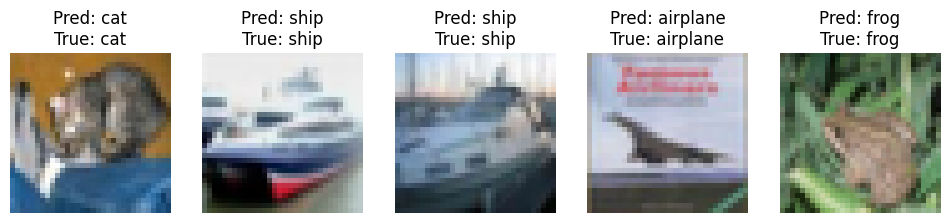

In [21]:
import matplotlib.pyplot as plt

# --- 결과 시각화 ---
plt.figure(figsize=(12, 4))
for i, img in enumerate(sample_images):
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    # 이미지 제목에 예측 결과와 실제 정답 표시
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {true_labels[i]}")
    plt.axis('off')
plt.show()

### HuggingFace Pipeline 사용

HuggingFace의 [pipeline](https://huggingface.co/docs/transformers/main_classes/pipelines)을 사용하면 위 과정을 더 간단하게 처리할 수도 있습니다.

이와 같이 하면 이미지마다 예측된 레이블과 신뢰도(score)를 쉽게 얻을 수 있습니다. pipeline은 내부적으로 image processor와 모델 예측 과정을 캡슐화하여 편의성을 제공합니다.

In [22]:
from transformers import pipeline
# 이미지 분류 파이프라인 생성
clf = pipeline(task="image-classification", model=model_name, device=device)

preds = clf(sample_images)
print(preds)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


[[{'label': 'LABEL_3', 'score': 0.9927236437797546}, {'label': 'LABEL_5', 'score': 0.0012952439719811082}, {'label': 'LABEL_9', 'score': 0.0009297917713411152}, {'label': 'LABEL_0', 'score': 0.0008214296540245414}, {'label': 'LABEL_8', 'score': 0.0007351302192546427}], [{'label': 'LABEL_8', 'score': 0.9955234527587891}, {'label': 'LABEL_1', 'score': 0.0007332785753533244}, {'label': 'LABEL_0', 'score': 0.0005330527783371508}, {'label': 'LABEL_2', 'score': 0.0005047415033914149}, {'label': 'LABEL_4', 'score': 0.0005029547610320151}], [{'label': 'LABEL_8', 'score': 0.9930387139320374}, {'label': 'LABEL_1', 'score': 0.002421507379040122}, {'label': 'LABEL_4', 'score': 0.0006866457988508046}, {'label': 'LABEL_9', 'score': 0.0006693329778499901}, {'label': 'LABEL_3', 'score': 0.0006172176799736917}], [{'label': 'LABEL_0', 'score': 0.9931061863899231}, {'label': 'LABEL_2', 'score': 0.0019252653000876307}, {'label': 'LABEL_3', 'score': 0.0007438044995069504}, {'label': 'LABEL_7', 'score': 0.0

In [23]:
# 예측 결과를 더 읽기 쉽게 출력
print("Pipeline 예측 결과:")
for i, pred_list in enumerate(preds):
    print(f"이미지 {i+1}:")
    for pred in pred_list:
        # 'LABEL_X' 문자열에서 레이블 인덱스 추출
        label_index = int(pred['label'].split('_')[1])
        print(f"  - 레이블: {labels[label_index]}, 신뢰도: {pred['score']:.4f}")

Pipeline 예측 결과:
이미지 1:
  - 레이블: cat, 신뢰도: 0.9927
  - 레이블: dog, 신뢰도: 0.0013
  - 레이블: truck, 신뢰도: 0.0009
  - 레이블: airplane, 신뢰도: 0.0008
  - 레이블: ship, 신뢰도: 0.0007
이미지 2:
  - 레이블: ship, 신뢰도: 0.9955
  - 레이블: automobile, 신뢰도: 0.0007
  - 레이블: airplane, 신뢰도: 0.0005
  - 레이블: bird, 신뢰도: 0.0005
  - 레이블: deer, 신뢰도: 0.0005
이미지 3:
  - 레이블: ship, 신뢰도: 0.9930
  - 레이블: automobile, 신뢰도: 0.0024
  - 레이블: deer, 신뢰도: 0.0007
  - 레이블: truck, 신뢰도: 0.0007
  - 레이블: cat, 신뢰도: 0.0006
이미지 4:
  - 레이블: airplane, 신뢰도: 0.9931
  - 레이블: bird, 신뢰도: 0.0019
  - 레이블: cat, 신뢰도: 0.0007
  - 레이블: horse, 신뢰도: 0.0007
  - 레이블: dog, 신뢰도: 0.0007
이미지 5:
  - 레이블: frog, 신뢰도: 0.9954
  - 레이블: automobile, 신뢰도: 0.0006
  - 레이블: airplane, 신뢰도: 0.0006
  - 레이블: ship, 신뢰도: 0.0005
  - 레이블: cat, 신뢰도: 0.0005


## 학생용 자가 체크리스트

- [ ] **전이학습 개념 이해**: 전이학습의 원리와 효과를 설명할 수 있고, Linear Probing과 Fine-tuning의 차이를 명확히 구분할 수 있다.
- [ ] **모델 수정 및 동결**: 사전 학습 모델의 분류층을 새로운 태스크에 맞게 수정하고, 특정 층의 파라미터를 동결/해제할 수 있다.
- [ ] **데이터 증강 적용**: RandomCrop, RandomHorizontalFlip 등의 증강 기법을 적용하고, 증강이 모델 성능에 미치는 영향을 분석할 수 있다.
- [ ] **PyTorch 학습 루프**: forward-backward pass, optimizer step, scheduler step을 포함한 완전한 학습 루프를 구현할 수 있다.
- [ ] **성능 평가 및 비교**: Linear Probing과 Fine-tuning의 성능 차이를 정량적으로 비교하고, 전이학습의 효과를 해석할 수 있다.
- [ ] **HuggingFace 활용**: HuggingFace Transformers 라이브러리를 사용하여 사전 학습 모델을 로드하고 추론을 수행할 수 있다.
- [ ] **전체 파이프라인 통합**: **[데이터 전처리 → Linear Probing → Fine-tuning → 평가]**로 이어지는 전이학습의 전체 과정을 독립적으로 수행하고 결과를 설명할 수 있다.

### **Content License Agreement**

<font color='red'><b>**WARNING**</b></font> : 본 자료는 삼성청년SW·AI아카데미의 컨텐츠 자산으로, 보안서약서에 의거하여 어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다.